In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

# Machine Learning utilities
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

# Handling class imbalance
from imblearn.over_sampling import SMOTE

# Machine Learning model
from sklearn.ensemble import RandomForestClassifier

# Model evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

Matplotlib is building the font cache; this may take a moment.


In [3]:
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")
display(df.head(10))
display(df.tail(10))
print(f"Dataset Shape: {df.shape}")

print("\nDataset Information:")
df.info()

print("\nSummary Statistics:")
display(df.describe(include="all"))

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
364,365,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
365,366,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
366,367,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
367,368,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
368,369,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
373,374,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


Dataset Shape: (374, 13)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
count,374.000000,374,374.000000,374,374.000000,374.000000,374.000000,374.000000,374,374,374.000000,374.000000,155
unique,NaN,2,NaN,11,NaN,NaN,NaN,NaN,4,25,NaN,NaN,2
top,NaN,Male,NaN,Nurse,NaN,NaN,NaN,NaN,Normal,130/85,NaN,NaN,Sleep Apnea
freq,NaN,189,NaN,73,NaN,NaN,NaN,NaN,195,99,NaN,NaN,78
mean,187.500000,NaN,42.184492,NaN,7.132086,7.312834,59.171123,5.385027,NaN,NaN,70.165775,6816.844920,NaN
std,108.108742,NaN,8.673133,NaN,0.795657,1.196956,20.830804,1.774526,NaN,NaN,4.135676,1617.915679,NaN
min,1.000000,NaN,27.000000,NaN,5.800000,4.000000,30.000000,3.000000,NaN,NaN,65.000000,3000.000000,NaN
25%,94.250000,NaN,35.250000,NaN,6.400000,6.000000,45.000000,4.000000,NaN,NaN,68.000000,5600.000000,NaN
50%,187.500000,NaN,43.000000,NaN,7.200000,7.000000,60.000000,5.000000,NaN,NaN,70.000000,7000.000000,NaN
75%,280.750000,NaN,50.000000,NaN,7.800000,8.000000,75.000000,7.000000,NaN,NaN,72.000000,8000.000000,NaN


## Data Cleaning

In [4]:
df = df.copy()
#To reduce noise, dropped:
df.drop(columns=["Person ID"], inplace=True)
df[["Systolic BP", "Diastolic BP"]] = (
    df["Blood Pressure"]
    .str.split("/", expand=True)
    .astype(int)
)

df.drop(columns=["Blood Pressure"], inplace=True)

df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")
display(df.head(10))

print("Updated Dataset Shape:", df.shape)

print("\nMissing Values:")
display(df.isnull().sum())

print("\nUpdated Data Types:")
display(df.dtypes)

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
0,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,None,126,83
1,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,None,125,80
3,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
5,Male,28,Software Engineer,5.9,4,30,8,Obese,85,3000,Insomnia,140,90
6,Male,29,Teacher,6.3,6,40,7,Obese,82,3500,Insomnia,140,90
7,Male,29,Doctor,7.8,7,75,6,Normal,70,8000,None,120,80
8,Male,29,Doctor,7.8,7,75,6,Normal,70,8000,None,120,80
9,Male,29,Doctor,7.8,7,75,6,Normal,70,8000,None,120,80


Updated Dataset Shape: (374, 13)

Missing Values:


Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
Systolic BP                0
Diastolic BP               0
dtype: int64


Updated Data Types:


Gender                         str
Age                          int64
Occupation                     str
Sleep Duration             float64
Quality of Sleep             int64
Physical Activity Level      int64
Stress Level                 int64
BMI Category                   str
Heart Rate                   int64
Daily Steps                  int64
Sleep Disorder                 str
Systolic BP                  int64
Diastolic BP                 int64
dtype: object

Missing Values


Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
Systolic BP                0
Diastolic BP               0
dtype: int64


Sleep Disorder Distribution


Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


Feature Skewness


Heart Rate                 1.224824
Diastolic BP               0.378570
Age                        0.257222
Daily Steps                0.178277
Stress Level               0.154330
Physical Activity Level    0.074487
Sleep Duration             0.037554
Systolic BP               -0.035669
Quality of Sleep          -0.207448
dtype: float64

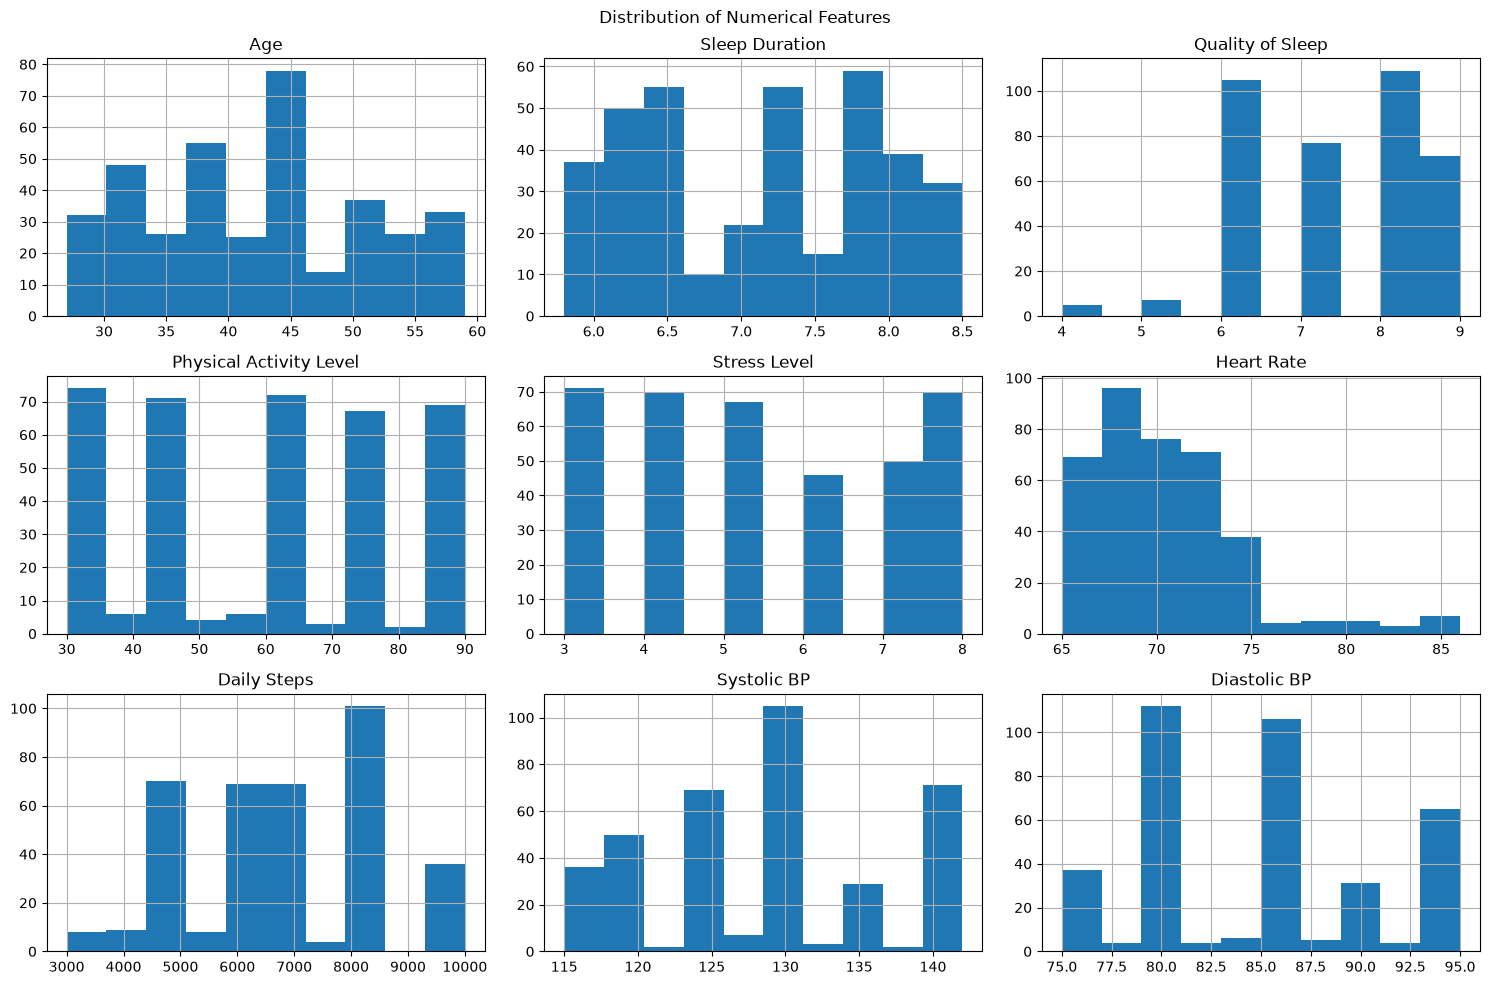

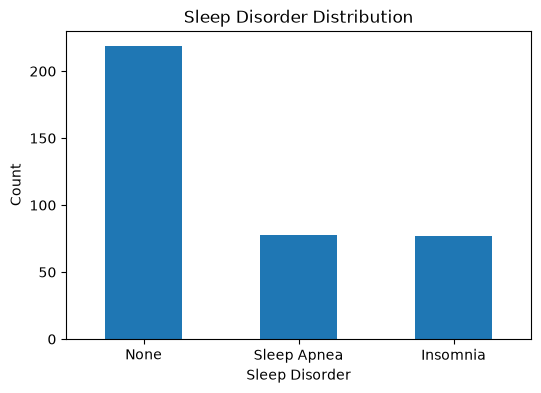

In [5]:
print("Missing Values")
display(df.isnull().sum())

print("\nSleep Disorder Distribution")
display(df["Sleep Disorder"].value_counts())

# Skewness of numerical features
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns
skewness = df[numerical_columns].skew().sort_values(ascending=False)

print("\nFeature Skewness")
display(skewness)

# Histograms
df[numerical_columns].hist(figsize=(15,10))
plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

# Target distribution graph
plt.figure(figsize=(6,4))
df["Sleep Disorder"].value_counts().plot(kind="bar")
plt.title("Sleep Disorder Distribution")
plt.xlabel("Sleep Disorder")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [6]:
import sklearn
print(sklearn.__version__)

1.9.0


## Synthetic Data Generation

In [7]:
target_size = 5200

# Number of synthetic samples needed
samples_needed = target_size - len(df)

# Randomly sampling with replacement
synthetic_df = df.sample(
    n=samples_needed,
    replace=True,
    random_state=42
).copy()

numerical_columns = [
    "Age",
    "Sleep Duration",
    "Quality of Sleep",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps",
    "Systolic BP",
    "Diastolic BP"
]

np.random.seed(42)

for column in numerical_columns:

    noise = np.random.normal(
        loc=0,
        scale=df[column].std() * 0.05,
        size=len(synthetic_df)
    )

    synthetic_df[column] = synthetic_df[column] + noise

# Keep values within realistic ranges
for column in numerical_columns:

    synthetic_df[column] = synthetic_df[column].clip(
        lower=df[column].min(),
        upper=df[column].max()
    )

integer_columns = [
    "Age",
    "Quality of Sleep",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps",
    "Systolic BP",
    "Diastolic BP"
]

synthetic_df[integer_columns] = synthetic_df[
    integer_columns
].round().astype(int)

# Combine original and synthetic data
df = pd.concat(
    [df, synthetic_df],
    ignore_index=True
)

# Shuffle dataset
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print(f"New Dataset Size: {len(df)}")

display(df.head())

New Dataset Size: 5200


,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
0,Male,44,Salesperson,6.246366,6,45,7,Overweight,72,5980,Insomnia,131,85
1,Male,33,Doctor,6.000000,6,30,8,Normal,72,5000,None,125,80
2,Female,52,Engineer,8.390160,9,31,3,Normal,65,4850,None,125,80
3,Female,50,Nurse,5.999083,6,90,8,Overweight,75,10000,None,140,95
4,Female,44,Teacher,6.624888,7,45,4,Overweight,65,5881,Insomnia,135,91


In [8]:
# Separate features and target
X = df.drop("Sleep Disorder", axis=1)
y = df["Sleep Disorder"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Set:")
print(X_train.shape)

print("\nTesting Set:")
print(X_test.shape)

Features Shape: (5200, 12)
Target Shape: (5200,)

Training Set:
(4160, 12)

Testing Set:
(1040, 12)


## Data Preprocessing

In [9]:
# Identify numerical and categorical columns
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns

categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical Features:")
print(list(numerical_features))

print("\nCategorical Features:")
print(list(categorical_features))


# Pipeline for numerical features
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# Pipeline for categorical features
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


# Combine both pipelines
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])


# Fit on training data only
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data
X_test_processed = preprocessor.transform(X_test)

print("Training data shape after preprocessing:", X_train_processed.shape)
print("Testing data shape after preprocessing:", X_test_processed.shape)

Numerical Features:
['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic BP', 'Diastolic BP']

Categorical Features:
['Gender', 'Occupation', 'BMI Category']
Training data shape after preprocessing: (4160, 26)
Testing data shape after preprocessing: (1040, 26)


## Handling Class Imbalance using SMOTE

In [10]:
print("Class Distribution Before SMOTE:")
print(y_train.value_counts())

# Apply SMOTE to the training data
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_processed,
    y_train
)

print("\nClass Distribution After SMOTE:")
print(y_train_balanced.value_counts())

print("\nBalanced Training Shape:")
print(X_train_balanced.shape)

Class Distribution Before SMOTE:
Sleep Disorder
None           2497
Insomnia        833
Sleep Apnea     830
Name: count, dtype: int64

Class Distribution After SMOTE:
Sleep Disorder
Sleep Apnea    2497
None           2497
Insomnia       2497
Name: count, dtype: int64

Balanced Training Shape:
(7491, 26)


In [11]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Training the model
rf_model.fit(
    X_train_balanced,
    y_train_balanced
)

print("Random Forest model trained successfully!")

# Training Accuracy
train_accuracy = rf_model.score(X_train_balanced, y_train_balanced)
print(f"Training Accuracy: {train_accuracy:.2%}")

Random Forest model trained successfully!
Training Accuracy: 99.73%


Test Accuracy: 90.48%

Classification Report:
              precision    recall  f1-score   support

    Insomnia       0.84      0.88      0.86       208
        None       0.95      0.91      0.93       625
 Sleep Apnea       0.85      0.90      0.87       207

    accuracy                           0.90      1040
   macro avg       0.88      0.90      0.89      1040
weighted avg       0.91      0.90      0.91      1040



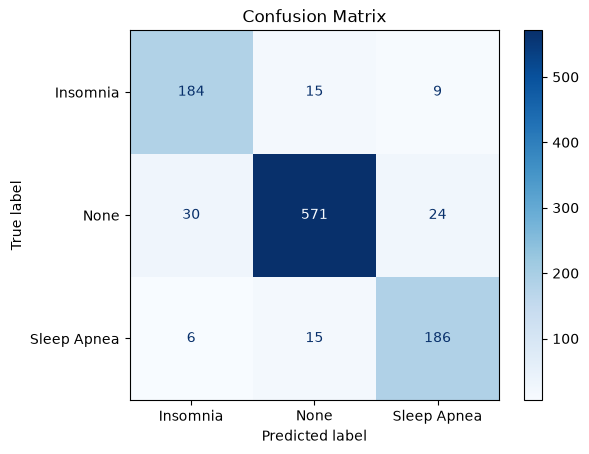

In [12]:
# Making predictions on the test set
y_pred = rf_model.predict(X_test_processed)


accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.2%}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_model.classes_
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [13]:
joblib.dump(rf_model, "models/rf_model.pkl")
joblib.dump(preprocessor, "models/preprocessor.pkl")
print("Model and preprocessor saved successfully!")

Model and preprocessor saved successfully!
